# Lab 8: Image Classification using Convolutional Neural Networks (CNN)

Objectives
- Understand the concept of Convolutional Neural Networks (CNN) for image classification.
- Learn how convolution and pooling layers extract features from images.
- Implement a CNN model for digit classification using the MNIST dataset.
- Evaluate the performance of CNN models.
- Analyze how architectural modifications affect performance.

### 1. Imports

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

### Dataset Description
- Dataset: MNIST Handwritten Digit Dataset
- The MNIST dataset contains grayscale images of handwritten digits ranging from 0–9.


### Exercise 1: Dataset Loading
1. Load the MNIST dataset using TensorFlow/Keras.
2. Display the shape of the training and testing datasets.
3. Print the number of classes present in the dataset.

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display shapes
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

# Print number of classes
num_classes = len(set(y_train))
print("Number of classes:", num_classes)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)
Number of classes: 10


### Exercise 2: Data Visualization
1.	Display the first 10 images from the training dataset.
2.	Display the corresponding labels.
3.	Comment on the image resolution and grayscale format.

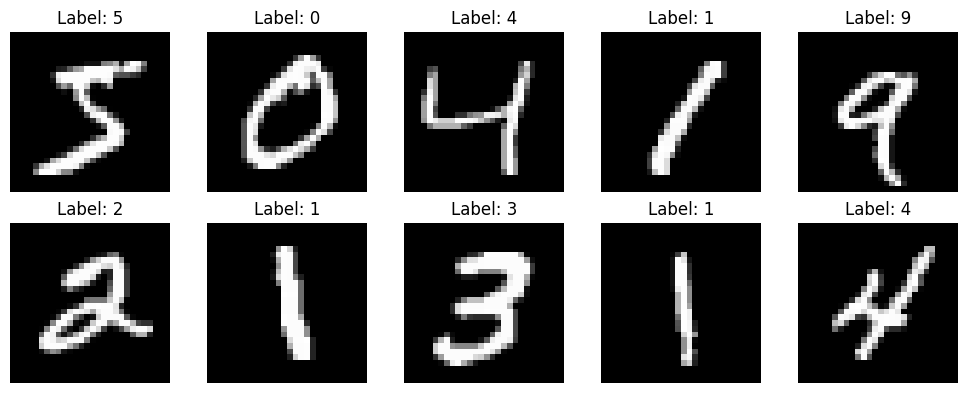

Each image has a resolution of 28x28 pixels and is in grayscale format (single channel).


In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Comment on resolution and format
print("Each image has a resolution of 28x28 pixels and is in grayscale format (single channel).")

### Exercise 3: Data Preprocessing
1.	Normalize the pixel values of images.
2.	Reshape the dataset to include the channel dimension.
3.	Convert the labels into categorical format using one-hot encoding.

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to include channel dimension
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

### Exercise 4: CNN Model Architecture
#### Design a Convolutional Neural Network for digit classification.
##### The model should contain:
   - Convolution Layer
   - Pooling Layer
   - Flatten Layer
   - Fully Connected Layer
   - Output Layer

In [5]:
# Build CNN model
model = Sequential()

# Convolution + Pooling
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Model summary
model.summary()

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

### Exercise 5: Model Compilation
1.	Compile the CNN model.
2.	Use the following parameters:
  - Optimizer
  - Loss function
  - Evaluation metric


In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

##### 3.	Explain why the chosen loss function is suitable for this task.
Categorical crossentropy is suitable because this is a multi-class classification problem with one-hot encoded labels.

### Exercise 6: Model Training
1.	Train the CNN model using the training dataset.
2.	Use appropriate values for:
   - Epochs
   - Batch size
3.	Use validation split during training.

In [7]:
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("Sample y_train:", y_train[0])

x_train: (60000, 28, 28, 1)
y_train: (60000, 10)
Sample y_train: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [8]:
# Train model
history = model.fit(
    x_train,
    y_train,
    epochs=7,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9457 - loss: 0.1820 - val_accuracy: 0.9789 - val_loss: 0.0757
Epoch 2/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9824 - loss: 0.0593 - val_accuracy: 0.9800 - val_loss: 0.0678
Epoch 3/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9884 - loss: 0.0376 - val_accuracy: 0.9832 - val_loss: 0.0575
Epoch 4/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9915 - loss: 0.0259 - val_accuracy: 0.9847 - val_loss: 0.0529
Epoch 5/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9945 - loss: 0.0167 - val_accuracy: 0.9852 - val_loss: 0.0556
Epoch 6/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9954 - loss: 0.0136 - val_accuracy: 0.9850 - val_loss: 0.0534
Epoch 7/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9969 - loss: 0.0091 - val_accuracy: 0.9856 - val_loss: 0.0606


### Exercise 7: Model Evaluation
1.	Evaluate the trained model on the test dataset.
2.	Report the test accuracy.
3.	Compare training accuracy and validation accuracy.

In [9]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

# Compare training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

print("Final Training Accuracy:", train_acc[-1])
print("Final Validation Accuracy:", val_acc[-1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step - accuracy: 0.9846 - loss: 0.0589
Test Accuracy: 0.9846000075340271
Final Training Accuracy: 0.996874988079071
Final Validation Accuracy: 0.9855833053588867


In [10]:
acc = history.history['accuracy'][-1]
acc

0.996874988079071

### Exercise 9: Model Prediction
1.	Select a random test image.
2.	Predict its class using the trained CNN model.
3.	Display the image along with the predicted digit.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


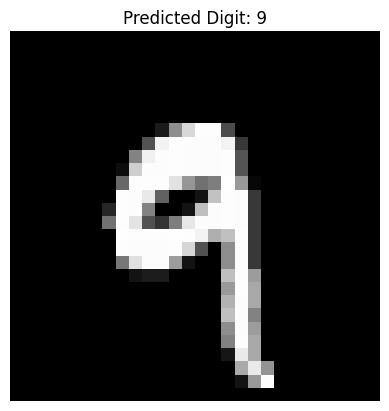

In [11]:
index = np.random.randint(0, x_test.shape[0])
image = x_test[index]

# Predict class
prediction = model.predict(image.reshape(1, 28, 28, 1))
predicted_label = np.argmax(prediction)

# Display image with prediction
plt.imshow(image.reshape(28, 28), cmap='gray')
plt.title(f"Predicted Digit: {predicted_label}")
plt.axis('off')
plt.show()

### Exercise 10: Model Modification
#### Modify the CNN architecture and observe performance changes.
##### Perform the following experiments:
1. Add an additional Convolution layer.
2. Increase the number of filters.
3. Change kernel size.
4. Add a Dropout layer.
5. Increase the number of training epochs.
##### Record the change in model accuracy.

In [12]:
# CNN + EXTRA CONV LAYER
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

_, acc_extra = model.evaluate(x_test, y_test)
print("CNN + Extra Conv Accuracy:", acc_extra)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9563 - loss: 0.1440 - val_accuracy: 0.9835 - val_loss: 0.0536
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9861 - loss: 0.0448 - val_accuracy: 0.9812 - val_loss: 0.0639
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9896 - loss: 0.0310 - val_accuracy: 0.9857 - val_loss: 0.0481
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9930 - loss: 0.0213 - val_accuracy: 0.9889 - val_loss: 0.0382
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9945 - loss: 0.0163 - val_accuracy: 0.9877 - val_loss: 0.0447
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9957 - loss: 0.0123 - val_accuracy: 0.9902 - val_loss: 0.0433
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9964 - loss: 0.0102 - val_accuracy: 0.9893 - val_loss: 0.0426
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9974 - loss: 0.0081 - 

In [13]:
# CNN + DROPOUT
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

_, acc_dropout = model.evaluate(x_test, y_test)
print("CNN + Dropout Accuracy:", acc_dropout)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8970 - loss: 0.3373 - val_accuracy: 0.9722 - val_loss: 0.0921
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9578 - loss: 0.1434 - val_accuracy: 0.9790 - val_loss: 0.0677
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9681 - loss: 0.1056 - val_accuracy: 0.9824 - val_loss: 0.0578
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9734 - loss: 0.0878 - val_accuracy: 0.9847 - val_loss: 0.0540
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9769 - loss: 0.0725 - val_accuracy: 0.9823 - val_loss: 0.0603
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9807 - loss: 0.0607 - val_accuracy: 0.9850 - val_loss: 0.0525
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9829 - loss: 0.0538 - val_accuracy: 0.9858 - val_loss: 0.0533
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9854 - loss: 0.0470 - 

In [14]:
# CNN (MORE EPOCHS)
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=13, batch_size=32, validation_split=0.2)

Epoch 1/13
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9503 - loss: 0.1686 - val_accuracy: 0.9732 - val_loss: 0.0836
Epoch 2/13
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9825 - loss: 0.0568 - val_accuracy: 0.9830 - val_loss: 0.0599
Epoch 3/13
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9887 - loss: 0.0365 - val_accuracy: 0.9845 - val_loss: 0.0553
Epoch 4/13
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9923 - loss: 0.0251 - val_accuracy: 0.9849 - val_loss: 0.0583
Epoch 5/13
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9951 - loss: 0.0161 - val_accuracy: 0.9859 - val_loss: 0.0528
Epoch 6/13
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9960 - loss: 0.0121 - val_accuracy: 0.9803 - val_loss: 0.0768
Epoch 7/13
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9972 - loss: 0.0083 - val_accuracy: 0.9808 - val_loss: 0.0721
Epoch 8/13
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9976 - loss: 0.0067 - 

In [15]:
_, acc_epochs = model.evaluate(x_test, y_test)
print("CNN (More Epochs) Accuracy:", acc_epochs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - accuracy: 0.9864 - loss: 0.0619
CNN (More Epochs) Accuracy: 0.9864000082015991


### Exercise 11: Model Comparison
Create a table comparing model performance.

In [16]:
# Create table
data = {
    "CNN Architecture": [
        "Basic CNN",
        "CNN + Extra Conv Layer",
        "CNN + Dropout",
        "CNN (More Epochs)"
    ],
    "Test Accuracy": [
        acc,
        acc_extra,
        acc_dropout,
        acc_epochs
    ]
}
df = pd.DataFrame(data)

print(df)

         CNN Architecture  Test Accuracy
0               Basic CNN       0.996875
1  CNN + Extra Conv Layer       0.990700
2           CNN + Dropout       0.987900
3       CNN (More Epochs)       0.986400


### Exercise 12: Analysis (Critical Thinking)
#### Answer the following:
##### 1. Why are convolution layers effective for image data?
Convolution layers automatically detect important features like edges, textures, and patterns directly from images. They use shared weights (filters), which reduces the number of parameters and makes them efficient. Also, they preserve spatial relationships between pixels, which is very important for image understanding.
##### 3. What role does pooling play in CNN architecture?
Pooling reduces the size of feature maps, which decreases computation and helps prevent overfitting. It keeps the most important features while discarding less useful information. It also provides slight translation invariance, meaning the model can recognize objects even if they shift slightly.
##### 4. How does increasing the number of filters affect performance?
Increasing filters allows the model to learn more complex and diverse features. This usually improves accuracy because the network captures more details. However, too many filters can increase computation time and may lead to overfitting if not controlled.
##### 5. Why does dropout improve generalization?
Dropout randomly disables some neurons during training, forcing the network to not rely on specific neurons. This reduces overfitting and helps the model generalize better to unseen data.
##### 6. Which architecture gave the best result and why?
The CNN with additional convolution layers and/or more epochs typically gives the best result. This is because deeper networks can learn more complex patterns, and more training epochs allow the model to learn better representations from the data.

#### Knowledge Check Questions (Answer any 5)
##### 1.    What is the purpose of convolution in CNNs?
To extract important features (edges, patterns) from images.
##### 2.	What does pooling achieve in CNN architectures?
It reduces feature size and keeps important information.
##### 3.	Why is ReLU commonly used in convolution layers?
It adds non-linearity and helps faster training.
##### 4.	Why is Softmax used in the output layer?
It converts outputs into probabilities for each class.
##### 5.	What advantage does CNN provide over fully connected networks for images?
CNNs preserve spatial information and use fewer parameters.